In [105]:
#House-Price-Prediction using Linear,Lasso and Ridge Regression

#Problem statement:
#The objective of this project is to predict the sale price of houses using machine learning regression models. We will analyze the dataset, preprocess the data, build multiple regression models, compare their performance, and determine the best-performing model.

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")
%matplotlib inline

In [107]:
df=pd.read_csv("../data/train.csv")

In [108]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [109]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [110]:
df.shape

(1460, 81)

In [111]:
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [112]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [113]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [114]:
print("rows",df.shape[0])
print("columns",df.shape[1])

rows 1460
columns 81


In [115]:
df.dtypes

Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 81, dtype: object

In [116]:
numerical_columns=df.select_dtypes(include=["int64","float64"]).columns
categorical_columns=df.select_dtypes(include=["object"]).columns
print("Number of numerical columns:",len(numerical_columns))
print("Number of categorical columns:",len(categorical_columns))

Number of numerical columns: 38
Number of categorical columns: 43


In [117]:
missing_values=df.isnull().sum()
missing_values

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [118]:

missing_values=missing_values[missing_values>0]
missing_values.sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [119]:
df["SalePrice"].head()

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64

In [120]:
df["SalePrice"].dtype

dtype('int64')

In [121]:
df["SalePrice"].info()

<class 'pandas.Series'>
RangeIndex: 1460 entries, 0 to 1459
Series name: SalePrice
Non-Null Count  Dtype
--------------  -----
1460 non-null   int64
dtypes: int64(1)
memory usage: 11.5 KB


In [122]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

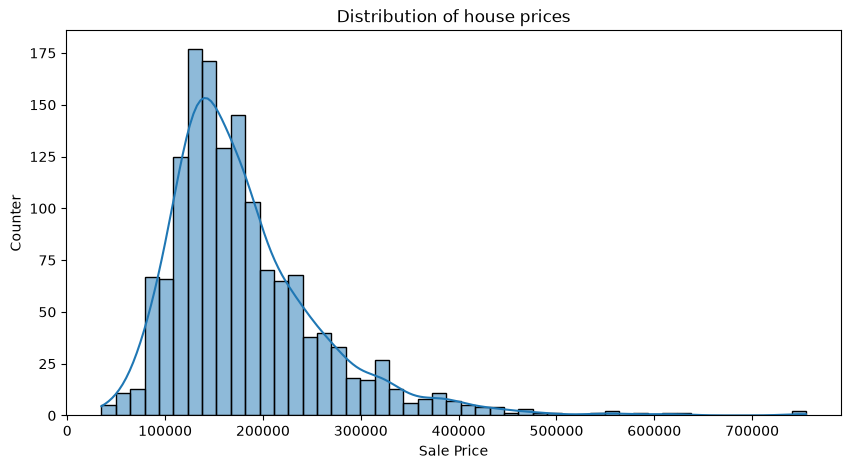

In [123]:
plt.figure(figsize=(10,5))
sns.histplot(df["SalePrice"],kde=True)
plt.title("Distribution of house prices")
plt.xlabel("Sale Price")
plt.ylabel("Counter")
plt.show()


In [124]:
duplicates=df.duplicated().sum()
print("duplicates rows are-->",duplicates)

duplicates rows are--> 0


In [125]:
missing_values_pct=(df.isnull().sum()/len(df))*100
missing_values_pct=missing_values_pct[missing_values_pct>0]
missing_values_pct=missing_values_pct.sort_values(ascending=False)
missing_values_pct

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

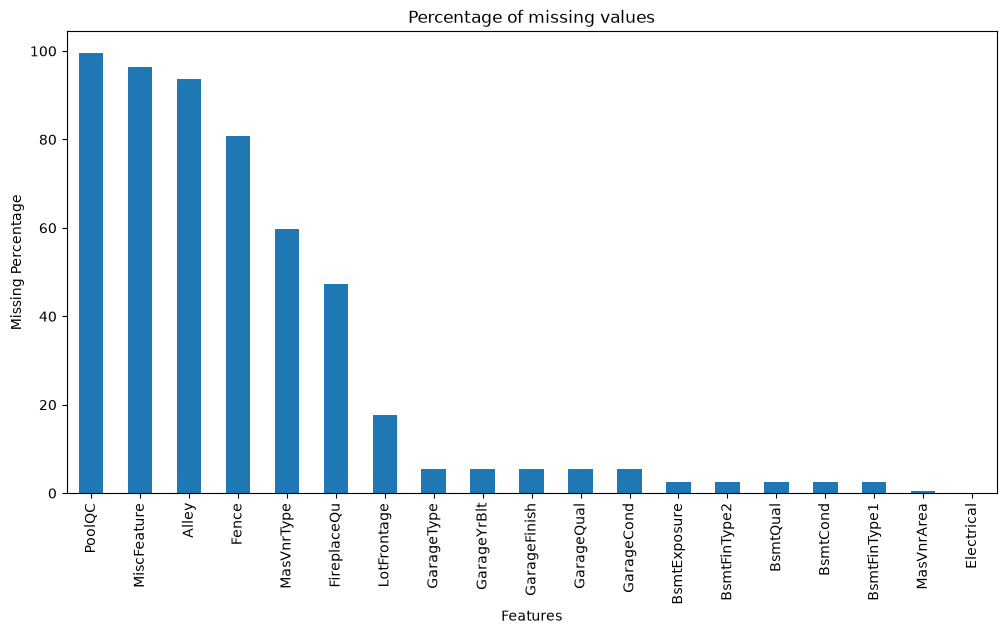

In [126]:
plt.figure(figsize=(12,6))
missing_values_pct.plot(kind="bar")
plt.title("Percentage of missing values")
plt.xlabel("Features")
plt.ylabel("Missing Percentage")
plt.xticks(rotation=90)
plt.show()

In [127]:
numerical_columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='str')

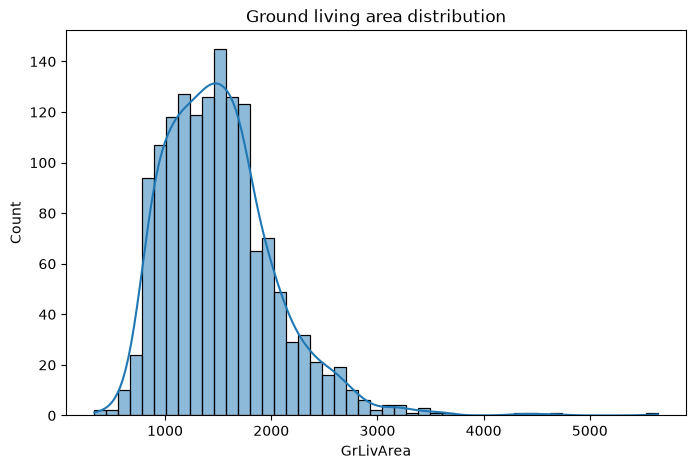

In [128]:
#distribution of numerical features
plt.figure(figsize=(8,5))
sns.histplot(df["GrLivArea"],kde=True)
plt.title("Ground living area distribution")
plt.show()

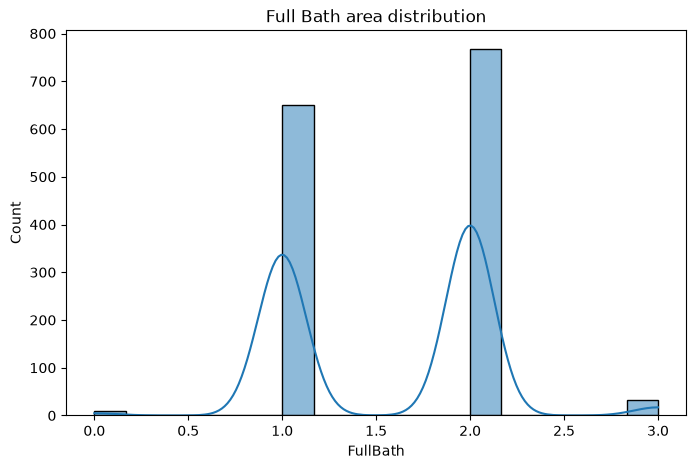

In [129]:
plt.figure(figsize=(8,5))
sns.histplot(df["FullBath"],kde=True)
plt.title("Full Bath area distribution")
plt.show()

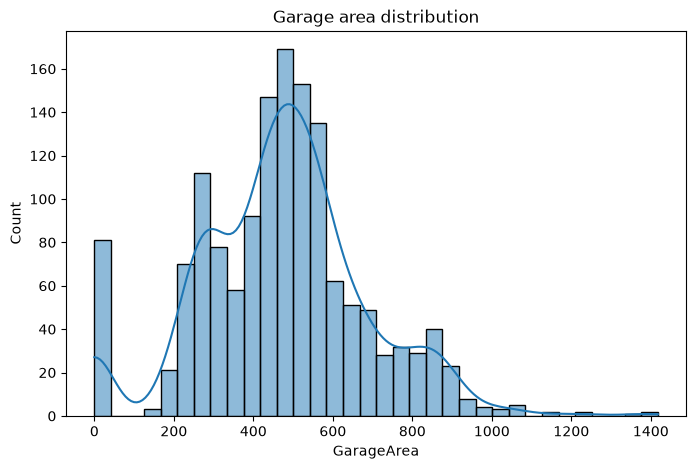

In [130]:
plt.figure(figsize=(8,5))
sns.histplot(df["GarageArea"],kde=True)
plt.title("Garage area distribution")
plt.show()

In [131]:
len(categorical_columns)

43

In [132]:
categorical_columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')

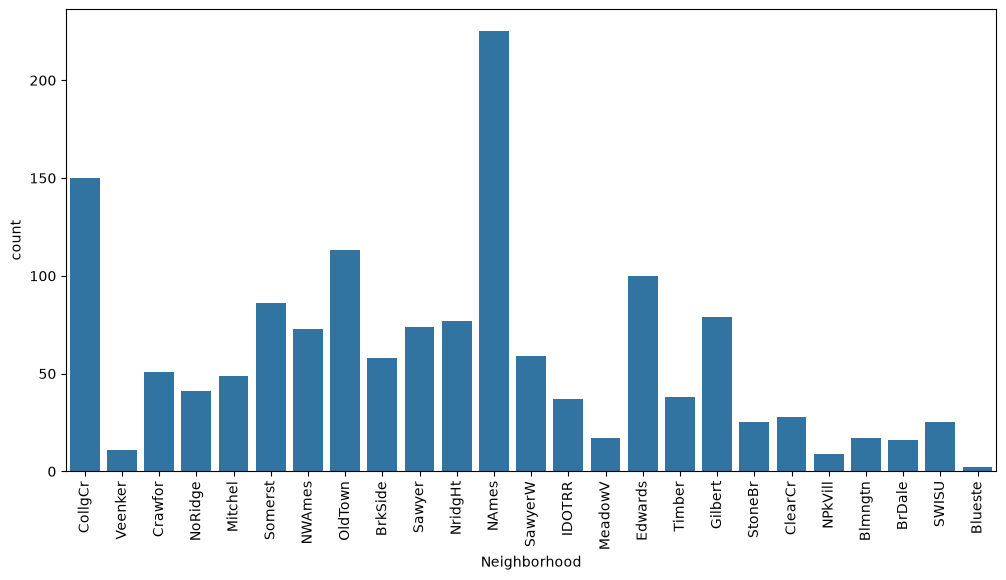

In [133]:
#Categorical feature analysis
plt.figure(figsize=(12,6))
sns.countplot(x="Neighborhood",data=df)
plt.xticks(rotation=90)
plt.show()

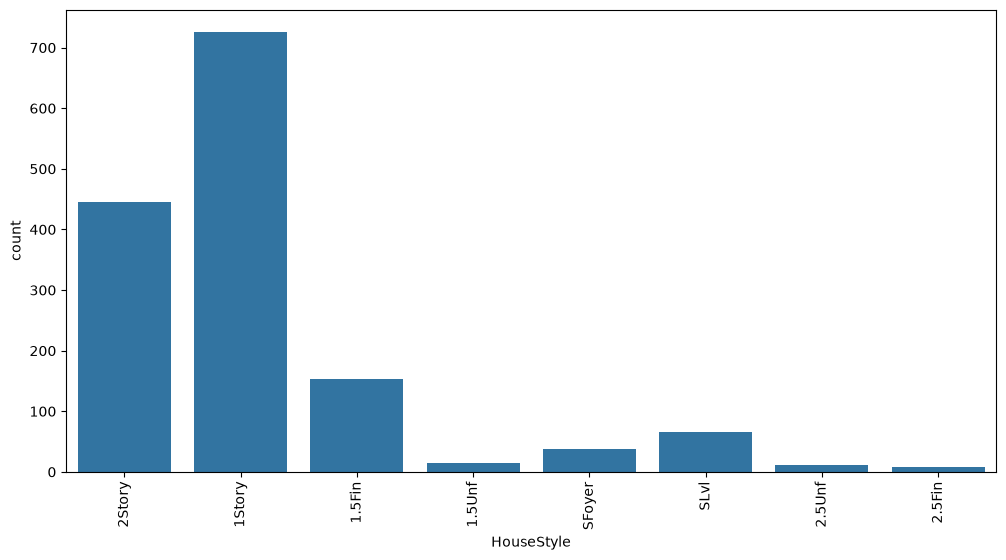

In [134]:
plt.figure(figsize=(12,6))
sns.countplot(x="HouseStyle",data=df)
plt.xticks(rotation=90)
plt.show()

In [135]:
#Correlation analysis
cr_matrix=df.corr(numeric_only=True)
cr_matrix

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,...,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917
MSSubClass,0.011156,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.010601,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.033226,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,-0.028365,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,0.012609,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,-0.012713,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,-0.021998,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,-0.050298,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.005024,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420


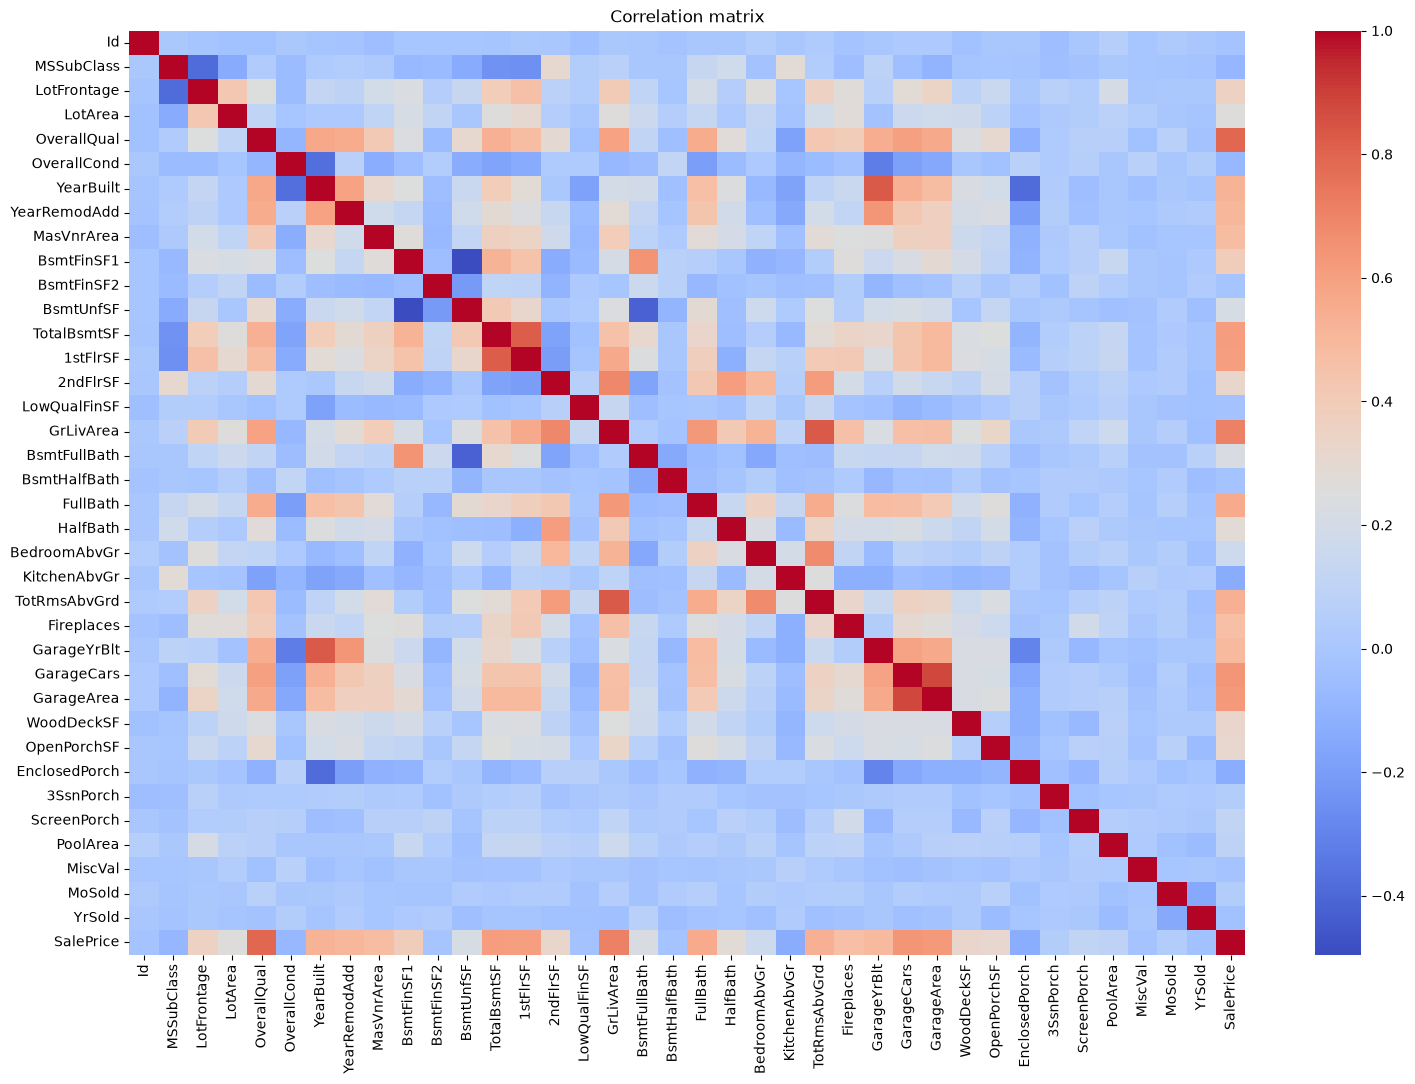

In [136]:
plt.figure(figsize=(18,12))
sns.heatmap(cr_matrix,cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

In [137]:
#features correlated with SalePrice
sale_cr=cr_matrix["SalePrice"].sort_values(ascending=True)
sale_cr

KitchenAbvGr    -0.135907
EnclosedPorch   -0.128578
MSSubClass      -0.084284
OverallCond     -0.077856
YrSold          -0.028923
LowQualFinSF    -0.025606
Id              -0.021917
MiscVal         -0.021190
BsmtHalfBath    -0.016844
BsmtFinSF2      -0.011378
3SsnPorch        0.044584
MoSold           0.046432
PoolArea         0.092404
ScreenPorch      0.111447
BedroomAbvGr     0.168213
BsmtUnfSF        0.214479
BsmtFullBath     0.227122
LotArea          0.263843
HalfBath         0.284108
OpenPorchSF      0.315856
2ndFlrSF         0.319334
WoodDeckSF       0.324413
LotFrontage      0.351799
BsmtFinSF1       0.386420
Fireplaces       0.466929
MasVnrArea       0.477493
GarageYrBlt      0.486362
YearRemodAdd     0.507101
YearBuilt        0.522897
TotRmsAbvGrd     0.533723
FullBath         0.560664
1stFlrSF         0.605852
TotalBsmtSF      0.613581
GarageArea       0.623431
GarageCars       0.640409
GrLivArea        0.708624
OverallQual      0.790982
SalePrice        1.000000
Name: SalePr

In [138]:
sale_cr.head()

KitchenAbvGr    -0.135907
EnclosedPorch   -0.128578
MSSubClass      -0.084284
OverallCond     -0.077856
YrSold          -0.028923
Name: SalePrice, dtype: float64

In [139]:
sale_cr.tail()

GarageArea     0.623431
GarageCars     0.640409
GrLivArea      0.708624
OverallQual    0.790982
SalePrice      1.000000
Name: SalePrice, dtype: float64

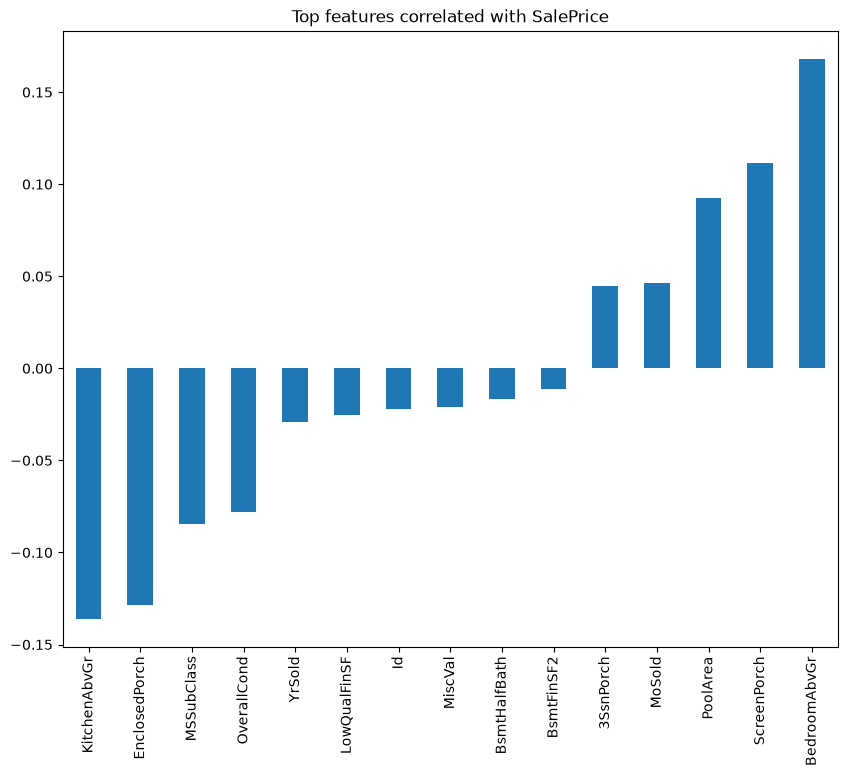

In [140]:
plt.figure(figsize=(10,8))
sale_cr.head(15).plot(kind="bar")
plt.title("Top features correlated with SalePrice")
plt.show()

In [141]:
df["Neighborhood"].value_counts()

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

In [142]:
#create a copy of dataset
data=df.copy()

In [143]:
#Removing Id column cause it has no predictive value
data.drop("Id",axis=1,inplace=True)

In [144]:
data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [145]:
missing_values=data.isnull().sum()
missing_values=missing_values[missing_values>0]
missing_values.sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [146]:
categorical_fill_none = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "MasVnrType"
]
for column in categorical_fill_none:
    data[column]=data[column].fillna("None")

In [147]:
data[categorical_fill_none].isnull().sum()

PoolQC          0
MiscFeature     0
Alley           0
Fence           0
FireplaceQu     0
GarageType      0
GarageFinish    0
GarageQual      0
GarageCond      0
BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
MasVnrType      0
dtype: int64

In [148]:
numerical_fill_median = [
    "LotFrontage",
    "GarageYrBlt",
    "MasVnrArea"
]

for column in numerical_fill_median:
    data[column] = data[column].fillna(data[column].median())

In [149]:
data[numerical_fill_median].isnull().sum()

LotFrontage    0
GarageYrBlt    0
MasVnrArea     0
dtype: int64

In [150]:
data["Electrical"]=data["Electrical"].fillna(data["Electrical"].mode()[0])

In [151]:
data["Electrical"].isnull().sum()

np.int64(0)

In [152]:
data.isnull().sum().sum()

np.int64(0)

In [153]:
x=data.drop("SalePrice",axis=1,)
y=data["SalePrice"]

In [154]:
print(x.shape)
print(y.shape)

(1460, 79)
(1460,)


In [155]:
#One hot encoding
x=pd.get_dummies(x,drop_first=True)

In [156]:
x.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,False,False,False,False,True,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,False,False,False,False,True,False,False,False,True,False
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,False,False,False,False,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,False,False,False,False,True,False,False,False,True,False


In [157]:
print(x.shape)

(1460, 259)


In [158]:
x.dtypes.value_counts()

bool       223
int64       33
float64      3
Name: count, dtype: int64

In [159]:
#shows first 10 columns
x.iloc[:,:10]

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2
0,60,65.0,8450,7,5,2003,2003,196.0,706,0
1,20,80.0,9600,6,8,1976,1976,0.0,978,0
2,60,68.0,11250,7,5,2001,2002,162.0,486,0
3,70,60.0,9550,7,5,1915,1970,0.0,216,0
4,60,84.0,14260,8,5,2000,2000,350.0,655,0
...,...,...,...,...,...,...,...,...,...,...
1455,60,62.0,7917,6,5,1999,2000,0.0,0,0
1456,20,85.0,13175,6,6,1978,1988,119.0,790,163
1457,70,66.0,9042,7,9,1941,2006,0.0,275,0
1458,20,68.0,9717,5,6,1950,1996,0.0,49,1029


In [160]:
from sklearn.model_selection import train_test_split


In [161]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,)

In [162]:
print("X_train shape:", x_train.shape)
print("X_test shape :", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (1168, 259)
X_test shape : (292, 259)
y_train shape: (1168,)
y_test shape : (292,)


In [163]:
from sklearn.linear_model import LinearRegression 

In [164]:
lr=LinearRegression()

In [165]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](259,)","[ -90.3 , -131.79, 0.67,..., 6258.36, 7870.04,19098.33]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](259,)","['MSSubClass','LotFrontage','LotArea',...,'SaleCondition_Family', 'SaleCondition_Normal','SaleCondition_Partial']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.485e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,259
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(240)


In [166]:
y_pred=lr.predict(x_test)

In [167]:
comparison=pd.DataFrame({
    "Actual price":y_test,
    "Predicted price":y_pred
})
comparison.head(10)

,Actual price,Predicted price
892,154500,159556.664652
1105,325000,341293.628075
413,115000,82825.808175
522,159000,188325.790360
1036,315500,315806.870743
614,75500,68929.656838
218,311500,253248.051399
1160,146000,144959.747305
649,84500,60617.528307
887,135500,158461.946372


In [168]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [169]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 20285.25450462644
MSE : 1106431454.9110422
RMSE: 33263.06442453915
R² Score: 0.8557517079424456


In [170]:
print(y.head())

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64


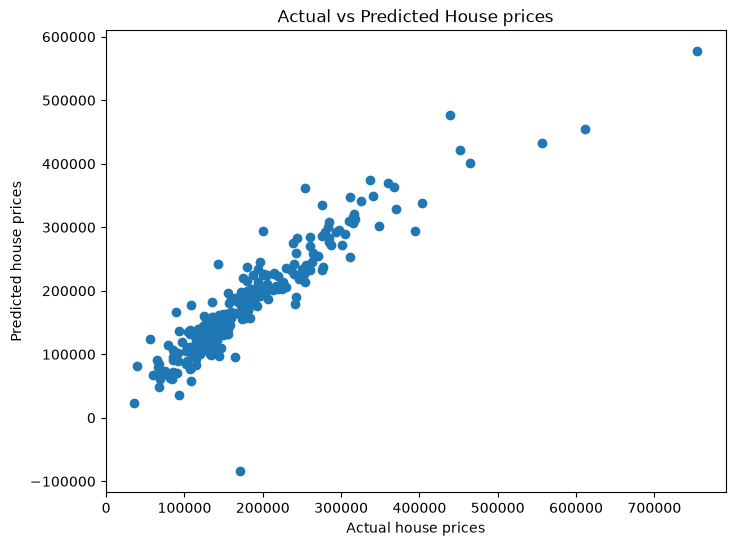

In [171]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual house prices")
plt.ylabel("Predicted house prices")
plt.title("Actual vs Predicted House prices")
plt.show()

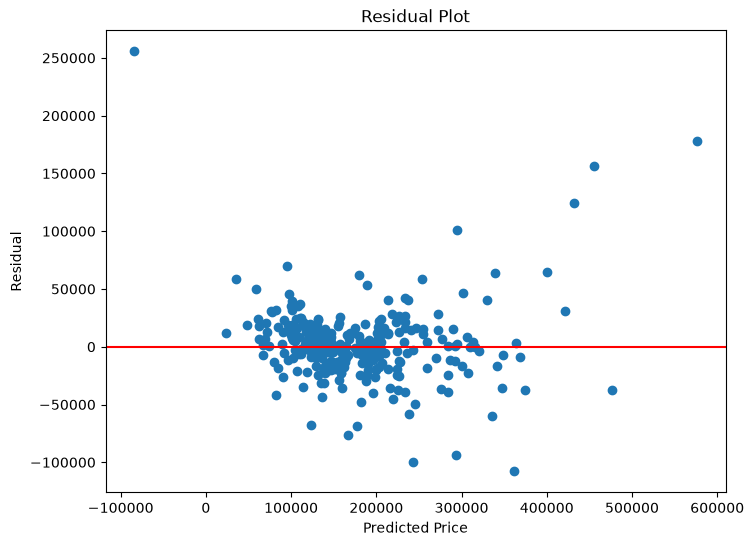

In [172]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

In [173]:
coef = pd.DataFrame({
    "Feature": x_train.columns,
    "Coefficient": lr.coef_
})

coef = coef.sort_values(by="Coefficient", ascending=False)

coef.head(10)

,Feature,Coefficient
117,RoofMatl_WdShngl,114918.605166
90,Condition2_PosA,81911.933226
190,Heating_Wall,72611.794396
111,RoofMatl_CompShg,71146.067848
255,SaleCondition_Alloca,57367.683932
168,BsmtCond_Po,50608.271121
114,RoofMatl_Roll,50605.410466
116,RoofMatl_WdShake,49543.389259
217,GarageType_CarPort,44473.273681
77,Neighborhood_StoneBr,39368.527424


In [174]:
from sklearn.linear_model import Ridge

In [175]:
ridge=Ridge(alpha=1.0)

In [176]:
#Scaling
from sklearn.preprocessing import StandardScaler

In [177]:
scaler = StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [178]:
ridge.fit(x_train_scaled,y_train)
ridge_pred=ridge.predict(x_test_scaled)

In [179]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [180]:
ridge_mae=mean_absolute_error(y_test,ridge_pred)
ridge_mse=mean_squared_error(y_test,ridge_pred)
ridge_rmse=ridge_mse**0.5
ridge_r2=r2_score(y_test,ridge_pred)
print("MAE :", ridge_mae)
print("MSE :", ridge_mse)
print("RMSE:", ridge_rmse)
print("R² :", ridge_r2)

MAE : 19649.880806413334
MSE : 1321068096.7016346
RMSE: 36346.500473933316
R² : 0.8277689812639535


In [181]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

ridge = Ridge()

param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    ridge,
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(x_train_scaled, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'alpha': 100}
0.7756654183835032


In [182]:
best_ridge = grid.best_estimator_

ridge_pred = best_ridge.predict(x_test_scaled)

print(r2_score(y_test, ridge_pred))

0.8612565595280193


In [183]:
from sklearn.linear_model import Lasso

In [184]:
l=Lasso(alpha=1.0)
l.fit(x_train_scaled,y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [185]:
l_pred=l.predict(x_test_scaled)

In [186]:
l_mae=mean_absolute_error(y_test,ridge_pred)
l_mse=mean_squared_error(y_test,ridge_pred)
l_rmse=l_mse**0.5
l_r2=r2_score(y_test,ridge_pred)
print("MAE :", l_mae)
print("MSE :", l_mse)
print("RMSE:", l_rmse)
print("R² :", l_r2)

MAE : 19995.5814124089
MSE : 1064207447.527541
RMSE: 32622.192561621927
R² : 0.8612565595280193


In [187]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso

l = Lasso(max_iter=10000)

param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 50, 100]
}

grid = GridSearchCV(
    estimator=l,
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(x_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'alpha': 100}
Best CV Score: 0.7111194050809662


In [188]:
best_lasso = grid.best_estimator_

lasso_pred = best_lasso.predict(x_test_scaled)

print("Test R²:", r2_score(y_test, lasso_pred))

Test R²: 0.8404954599842429


In [189]:
final_model=best_ridge

In [190]:
import joblib

In [202]:
joblib.dump(final_model,"house_price_model.pkl")

['house_price_model.pkl']

In [203]:
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [204]:
joblib.dump(x_train.columns.tolist(),"features.pkl")

['features.pkl']

In [201]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression (Default)",
        "Ridge Regression (Tuned)",
        "Lasso Regression (Default)",
        "Lasso Regression (Tuned)"
    ],
    "R² Score": [
        0.8557517079424456,
        0.8277689812639535,
        0.8612565595280193,
        0.8612565595280193,
        0.8404954599842429
    ]
})

comparison

,Model,R² Score
0,Linear Regression,0.855752
1,Ridge Regression (Default),0.827769
2,Ridge Regression (Tuned),0.861257
3,Lasso Regression (Default),0.861257
4,Lasso Regression (Tuned),0.840495


In [195]:
# Best Model

#Among all the models tested, the tuned Ridge Regression model achieved the highest R² score (0.8613).

#Therefore, Ridge Regression was selected as the final model for house price prediction.

In [196]:
# Conclusion

#This project predicts house prices using multiple regression algorithms.
#The workflow included:

#- Data Cleaning
#- Exploratory Data Analysis
#- Missing Value Handling
#- One-Hot Encoding
#- Train-Test Split
#- Linear Regression
#- Ridge Regression
#- Lasso Regression
#- Hyperparameter Tuning
#Among all the models, Tuned Ridge Regression achieved the best performance with an R² score of 0.8613.